In [60]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['Times'],'size':15})
rc('text', usetex=True)
rc('text.latex',unicode=True)
rc('text.latex',preamble='\\usepackage[utf8]{inputenc}')
rc('text.latex',preamble='\\usepackage[russian]{babel}')

from scipy.optimize import fsolve


In [152]:
def potential(r):
    return -1. / r + 0.6 / r**2# + 0.25

r_parabola = 0.6
r_hyperbola = 0.55
r_ellipse1 = 0.73508894
r_ellipse2 = 3.26491106
r_circle = 1.2

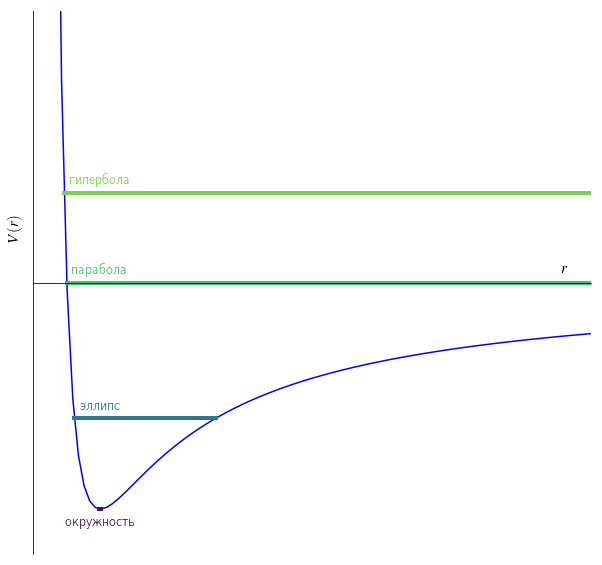

In [168]:
plt.figure(figsize=(10, 10))
ax = plt.subplot(111)
r_vals = np.linspace(0, 10, 100)
v_vals = potential(r_vals)
ax.plot(r_vals, v_vals, c='blue')
# ax.plot(r_vals, v_vals, c='k')

cmap = mpl.cm.viridis_r
ax.plot([r_hyperbola, 100], [potential(r_hyperbola), potential(r_hyperbola)], c=cmap(0.2), lw=4);
ax.text(r_hyperbola + 0.1, potential(r_hyperbola) + 0.01, "гипербола", color=cmap(0.2), ha='left', va='bottom');
ax.plot([r_parabola, 100], [0, 0], c=cmap(0.3), lw=4);
ax.text(r_parabola + 0.1, potential(r_parabola) + 0.01, "парабола", color=cmap(0.3), ha='left', va='bottom');
ax.plot([r_ellipse1, r_ellipse2], [potential(r_ellipse1), potential(r_ellipse2)], c=cmap(0.6), lw=4);
ax.text(r_ellipse1 + 0.1, potential(r_ellipse1) + 0.01, "эллипс", color=cmap(0.6), ha='left', va='bottom');
ax.plot([r_circle-0.02, r_circle+0.02], [potential(r_circle), potential(r_circle)], c=cmap(0.95), lw=4);
ax.text(r_circle, potential(r_circle) - 0.01, "окружность", color=cmap(0.95), ha='center', va='top');

ax.set_ylim(-0.5, 0.5)
ax.set_xlim(0, 10)
ax.spines['left'].set_position('zero')
ax.spines['right'].set_color('none')
ax.spines['bottom'].set_position('zero')
ax.spines['top'].set_color('none')

ax.yaxis.set_label_coords(-0.02, 0.6)
ax.xaxis.set_label_coords(0.95, 0.54)
ax.set_xticks([])
ax.set_yticks([]);
ax.set_xlabel(r'$r$');
ax.set_ylabel(u'$V(r)$');

plt.savefig('potential.png', dpi=300)

In [49]:
def potential(r):
    return -1. / r**3 + 1. / r**2# - 0.01 / r

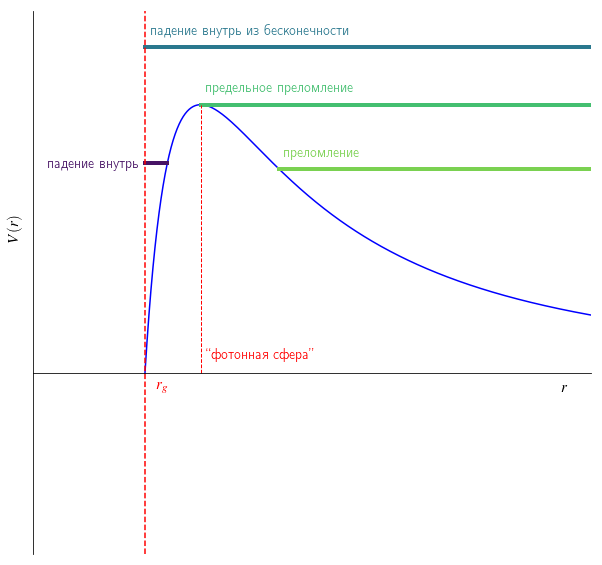

In [124]:
plt.figure(figsize=(10, 10))
ax = plt.subplot(111)
r_vals = np.linspace(1, 10, 1000)
v_vals = potential(r_vals)
ax.plot(r_vals, v_vals, c='blue')
# ax.plot(r_vals, v_vals, c='k')

cmap = mpl.cm.viridis_r
r_open = 2.2
ax.plot([r_open, 100], [potential(r_open), potential(r_open)], c=cmap(0.2), lw=4);
ax.text(r_open + 0.05, potential(r_open) + 0.005, 'преломление', color=cmap(0.2), ha='left', va='bottom');
r_limit = 1.5
ax.plot([r_limit, 100], [potential(r_limit), potential(r_limit)], c=cmap(0.3), lw=4);
ax.text(r_limit + 0.05, potential(r_limit) + 0.005, "предельное преломление", color=cmap(0.3), ha='left', va='bottom');
r_into = 1
ax.plot([r_into, 100], [0.18, 0.18], c=cmap(0.6), lw=4);
ax.text(r_into + 0.05, 0.18 + 0.005, "падение внутрь из бесконечности", color=cmap(0.6), ha='left', va='bottom');
r_in = 1.2
ax.plot([1, r_in], [potential(r_in), potential(r_in)], c=cmap(0.95), lw=4);
ax.text(1 - 0.05, potential(r_in), "падение внутрь", color=cmap(0.95), ha='right', va='center');

ax.plot([r_limit, r_limit], [0, potential(r_limit)], c='red', lw=1, ls='--');
ax.text(1.5 + 0.05, .01, r"``фотонная сфера''", color='red', ha='left', va='center');

ax.axvline(1, ls='--', c='red')
ax.text(1.1, -0.01, r'$r_g$', color='red')
ax.set_ylim(-0.1, 0.2)
ax.set_xlim(0, 5)
ax.spines['left'].set_position('zero')
ax.spines['right'].set_color('none')
ax.spines['bottom'].set_position('zero')
ax.spines['top'].set_color('none')

ax.yaxis.set_label_coords(-0.02, 0.6)
ax.xaxis.set_label_coords(0.95, 0.32)
ax.set_xticks([])
ax.set_yticks([]);
ax.set_xlabel(r'$r$');
ax.set_ylabel(u'$V(r)$');

plt.savefig('potential_phot.png', dpi=300)

In [166]:
def potential(r, l):
    return (-1. / r**3 + 1. / r**2 - l / r) * l**2 + 0.004

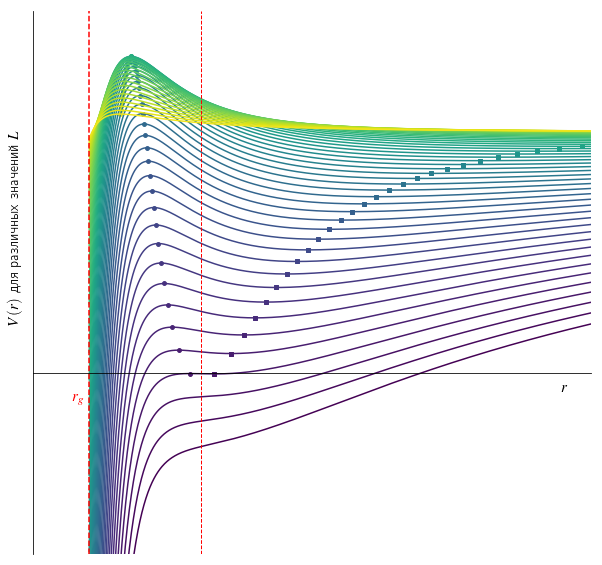

In [203]:
plt.figure(figsize=(10, 10))
ax = plt.subplot(111)
r_vals = np.linspace(1, 10, 1000)
cmap = mpl.cm.viridis
nn = 50
for i, l in enumerate(np.linspace(0.05, .35, nn)[::-1]):
    v_vals = potential(r_vals, l)
    ax.plot(r_vals, v_vals, c=cmap(1. * i / nn))

for i, l in enumerate(np.linspace(0.05, .35, nn)[::-1]):
    r_c = (1. + np.sqrt(1. - 3. * l)) / l
    ax.scatter([r_c], [potential(r_c, l)], s = 10, color=cmap(1. * i / nn), marker='s')
    r_c = (1. - np.sqrt(1. - 3. * l)) / l
    ax.scatter([r_c], [potential(r_c, l)], s = 15, color=cmap(1. * i / nn), marker='o')
# ax.plot(r_vals, v_vals, c='k')

# cmap = mpl.cm.viridis_r
# r_open = 2.2
# ax.plot([r_open, 100], [potential(r_open), potential(r_open)], c=cmap(0.2), lw=4);
# ax.text(r_open + 0.05, potential(r_open) + 0.005, 'преломление', color=cmap(0.2), ha='left', va='bottom');
# r_limit = 1.5
# ax.plot([r_limit, 100], [potential(r_limit), potential(r_limit)], c=cmap(0.3), lw=4);
# ax.text(r_limit + 0.05, potential(r_limit) + 0.005, "предельное преломление", color=cmap(0.3), ha='left', va='bottom');
# r_into = 1
# ax.plot([r_into, 100], [0.18, 0.18], c=cmap(0.6), lw=4);
# ax.text(r_into + 0.05, 0.18 + 0.005, "падение внутрь из бесконечности", color=cmap(0.6), ha='left', va='bottom');
# r_in = 1.2
# ax.plot([1, r_in], [potential(r_in), potential(r_in)], c=cmap(0.95), lw=4);
# ax.text(1 - 0.05, potential(r_in), "падение внутрь", color=cmap(0.95), ha='right', va='center');

# ax.plot([r_limit, r_limit], [0, potential(r_limit)], c='red', lw=1, ls='--');
# ax.text(1.5 + 0.05, .01, r"``фотонная сфера''", color='red', ha='left', va='center');

ax.axvline(3, ls='--', c='red', lw=1);

ax.axvline(1, ls='--', c='red')
ax.text(0.9, -0.0005, r'$r_g$', color='red', ha='right')
ax.set_ylim(-0.003, 0.006)
ax.set_xlim(0, 10)
ax.spines['left'].set_position('zero')
ax.spines['right'].set_color('none')
ax.spines['bottom'].set_position('zero')
ax.spines['top'].set_color('none')

ax.yaxis.set_label_coords(-0.02, 0.6)
ax.xaxis.set_label_coords(0.95, 0.32)
ax.set_xticks([])
ax.set_yticks([]);
ax.set_xlabel(r'$r$');
ax.set_ylabel(u'$V(r)$ для различных значений $L$');

# plt.savefig('potential_mass.png', dpi=300)